In [1]:
# ===================================================================
# CELL 1: IMPORTS & SETUP (Keep your existing one, no changes needed)
# ===================================================================
import os
import pandas as pd
import numpy as np
import re
import unicodedata
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    get_linear_schedule_with_warmup
)
from torch.utils.data import Dataset
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [2]:
# ===================================================================
# CELL 2: LOAD DATA (Keep your existing one, no changes needed)
# ===================================================================
from google.colab import drive
drive.mount('/content/drive')

os.environ["WANDB_DISABLED"] = "true"
file_path = '/content/drive/My Drive/MindShield/MindShield_Dataset_3.xlsx'

if os.path.exists(file_path):
    df = pd.read_excel(file_path)
    print(f"✓ Dataset Loaded: {df.shape[0]} rows")
    print(f"✓ Columns: {df.columns.tolist()}")
    display(df.head())
else:
    print(f"✗ File not found at {file_path}")

Mounted at /content/drive
✓ Dataset Loaded: 5000 rows
✓ Columns: ['Text', 'Risk_Level']


,Text,Risk_Level
0,eya awilla mata duka witharak ithuru karala ya...,Medium Risk
1,dan masaa hatharak wenawa daala gihin amathaka...,High Risk
2,Daala yanna nam sathekutawath adare karanna ep...,Medium Risk
3,Aluthen jeewitheta ena hama kenama magak awith...,Medium Risk
4,Pana wage adarei kiyala lan wela hitiyata koi ...,High Risk


In [3]:
# ===================================================================
# CELL 3: ENHANCED NORMALIZATION (REPLACE YOUR EXISTING CELL 3)
# ===================================================================
def normalize_sinhala_singlish_v2(text):
    """
    Enhanced normalization:
    - Removes stopwords
    - Preserves script (Sinhala stays Sinhala, Singlish stays Singlish)
    - Keeps original words for XAI
    """
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize("NFKC", text.lower())

    # STEP 1: STANDARDIZE VARIANTS
    SINGLISH_VARIANTS = [
        (r"\b(marenne|maranne|marenawa|merenna)\b", "marenna"),
        (r"\b(jeewithe\s*epa|jeewithe\s*epawela)\b", "jeewithe_epa"),
        (r"\b(siyadiwi\s*nasaganna)\b", "siyadiwi_nasaganna"),
        (r"\b(me\s*loken\s*yanna|loken\s*yanna)\b", "loken_yanna"),
        (r"\b(waha\s*kanna)\b", "waha_kanna"),
        (r"\b(jeewath\s*wenna\s*baa|jeewath\s*wenna\s*ba)\b", "jeewath_wenna_baha"),
        (r"\b(daraganna\s*baa|daraganna\s*ba)\b", "daraganna_baha"),
        (r"\b(manasika\s*peedanaya|manasikawa\s*watila)\b", "manasika_peedanaya"),
        (r"\b(papuwa\s*ridenawa|hadawatha\s*ridenawa)\b", "papuwa_ridenawa"),
        (r"\b(waira\s*karanawa)\b", "waira_karanawa"),
    ]

    SINHALA_VARIANTS = [
        (r"මැරෙන්න", "මරන්න"),
        (r"ජීවිතේ\s*එපා", "ජීවිතේ_එපා"),
        (r"සියදිවි\s*නසාගන්න", "සියදිවි_නසාගන්න"),
        (r"ලෝකෙන්\s*යන්න", "ලෝකෙන්_යන්න"),
        (r"වහ\s*කන්න", "වහ_කන්න"),
        (r"ජීවත්\s*වෙන්න\s*බෑ", "ජීවත්_වෙන්න_බෑ"),
        (r"දරාගන්න\s*බෑ", "දරාගන්න_බෑ"),
        (r"මානසික\s*පීඩනය", "මානසික_පීඩනය"),
        (r"පපුව\s*රිදෙනවා", "පපුව_රිදෙනවා"),
        (r"හදවත\s*රිදෙනවා", "හදවත_රිදෙනවා"),
        (r"වෛර\s*කරනවා", "වෛර_කරනවා"),
    ]

    for pattern, standard in SINGLISH_VARIANTS:
        text = re.sub(pattern, standard, text, flags=re.IGNORECASE)

    for pattern, standard in SINHALA_VARIANTS:
        text = re.sub(pattern, standard, text)

    # STEP 2: STOPWORD REMOVAL
    STOPWORDS = {
        'mama', 'mage', 'mata', 'mawa', 'api', 'ape', 'apiwa', 'oya', 'oyage',
        'oba', 'obage', 'eya', 'eyage', 'eka', 'eyala', 'meka', 'uba', 'ubage',
        'ohu', 'man', 'mam', 'mn', 'mt', 'mge', 'e',
        'මම', 'මට', 'මගේ', 'මාව', 'අපි', 'අපේ', 'ඔබ', 'ඔයා', 'එයා', 'එක', 'මේක',
        'mokakda', 'mokada', 'kawda', 'kohomada', 'kara', 'karanawa', 'gena', 'wena',
        'nisa', 'eth', 'saha', 'da', 'namuth', 'ane', 'wage', 'kiyala', 'ekka',
        'dan', 'ai', 'one', 'thamai', 'dn', 'oni', 'unath', 'hinda', 'ona',
        'නිසා', 'එත්', 'සහ', 'ද', 'නමුත්', 'දැන්', 'වගේ', 'කියලා', 'එක්ක', 'ඕනේ',
    }

    words = [w for w in text.split() if w not in STOPWORDS]
    text = ' '.join(words)

    # STEP 3: CORE NORMALIZATION
    SINGLISH_RULES = [
        (r"\b(ba|baa+|baha)\b", "baha"),
        (r"\b(epa|epaa+)\b", "epa"),
        (r"\b(na|naa)\b", "na"),
        (r"\b(duka|duki)\b", "duka"),
        (r"\b(dukai+|dukak)\b", "dukak"),
        (r"\b(wedana[a-z]*)\b", "wedanawa"),
        (r"\b(riden[a-z]*)\b", "ridenawa"),
        (r"\b(thani[a-z]*)\b", "thani"),
        (r"\b(thanikama[a-z]*)\b", "thanikama"),
        (r"\b(hithenawa|hithenav[a-z]*)\b", "hithenawa"),
        (r"\b(bari|baeri)\b", "bari"),
    ]

    SINHALA_RULES = [
        (r"බෑ", "බා"),
        (r"එපා+", "එපා"),
        (r"දුකයි", "දුක"),
        (r"තනියෙන්", "තනි"),
    ]

    for pattern, repl in SINGLISH_RULES:
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)

    for pattern, repl in SINHALA_RULES:
        text = re.sub(pattern, repl, text)

    # Clean URLs/extra spaces
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"([\U00010000-\U0010ffff])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply normalization
df['clean_text'] = df['Text'].apply(normalize_sinhala_singlish_v2)
print("✓ Enhanced normalization complete")

# Show examples
print("\n" + "="*60)
print("NORMALIZATION EXAMPLES")
print("="*60)
for i in range(min(5, len(df))):
    print(f"Original: {df['Text'].iloc[i][:80]}")
    print(f"Cleaned:  {df['clean_text'].iloc[i][:80]}")
    print("-"*60)

✓ Enhanced normalization complete

NORMALIZATION EXAMPLES
Original: eya awilla mata duka witharak ithuru karala yanawa
Cleaned:  awilla duka witharak ithuru karala yanawa
------------------------------------------------------------
Original: dan masaa hatharak wenawa daala gihin amathaka karanna hithenne na thaama puduma
Cleaned:  masaa hatharak wenawa daala gihin amathaka karanna hithenne na thaama puduma kar
------------------------------------------------------------
Original: Daala yanna nam sathekutawath adare karanna epa kiyala kiyapu yaaluwo.apiwa daal
Cleaned:  daala yanna nam sathekutawath adare karanna epa kiyapu yaaluwo.apiwa daala yanaw
------------------------------------------------------------
Original: Aluthen jeewitheta ena hama kenama magak awith daala yanawa.. Namuth hamadaama t
Cleaned:  aluthen jeewitheta ena hama kenama magak awith daala yanawa.. hamadaama thani da
------------------------------------------------------------
Original: Pana wage adarei kiyala lan w

In [4]:
# ===================================================================
# CELL 4: DATA CLEANING & AUGMENTATION (REPLACE YOUR CELL 4)
# ===================================================================
import random

# Remove empty rows
df = df.dropna(subset=['Text', 'Risk_Level'])
df['Risk_Level'] = df['Risk_Level'].astype(str).str.strip()
df = df[df['Risk_Level'].str.lower() != 'nan']
df = df[df['Risk_Level'] != '']

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['Risk_Level'])

# DATA AUGMENTATION
class SimpleAugmenter:
    def __init__(self):
        self.synonyms = {
            'duka': ['dukak', 'dukai'],
            'marenna': ['marila'],
            'thani': ['thanikama'],
            'baha': ['na', 'epa'],
        }

    def synonym_replace(self, text):
        words = text.split()
        new_words = words.copy()

        for i, word in enumerate(words):
            if word in self.synonyms and random.random() > 0.5:
                new_words[i] = random.choice(self.synonyms[word])

        return ' '.join(new_words)

    def random_swap(self, text):
        words = text.split()
        if len(words) >= 2:
            idx1, idx2 = random.sample(range(len(words)), 2)
            words[idx1], words[idx2] = words[idx2], words[idx1]
        return ' '.join(words)

    def augment(self, text):
        if random.random() > 0.5:
            return self.synonym_replace(text)
        else:
            return self.random_swap(text)

# Augment dataset (focus on High Risk)
augmenter = SimpleAugmenter()
augmented_data = []

for idx, row in df.iterrows():
    # Add original
    augmented_data.append(row.to_dict())

    # Augment High Risk more (2x), others 1x
    num_aug = 2 if row['Risk_Level'] == 'High Risk' else 1

    for _ in range(num_aug):
        aug_row = row.to_dict()
        aug_row['clean_text'] = augmenter.augment(row['clean_text'])
        augmented_data.append(aug_row)

df_augmented = pd.DataFrame(augmented_data)

print("="*60)
print("DATA AUGMENTATION COMPLETE")
print("="*60)
print(f"Original size: {len(df)}")
print(f"Augmented size: {len(df_augmented)}")
print("\nClass distribution:")
print(df_augmented['Risk_Level'].value_counts())

DATA AUGMENTATION COMPLETE
Original size: 5000
Augmented size: 11580

Class distribution:
Risk_Level
High Risk      4740
Medium Risk    3470
No Risk        3370
Name: count, dtype: int64


In [5]:
# ===================================================================
# CELL 5: DATA SPLIT (REPLACE YOUR CELL 5)
# ===================================================================
# Use augmented dataset
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_augmented['clean_text'],
    df_augmented['label'],
    test_size=0.20,
    random_state=42,
    stratify=df_augmented['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print("✓ Data Split Complete:")
print(f"  Training:   {len(train_texts)} samples")
print(f"  Validation: {len(val_texts)} samples")
print(f"  Testing:    {len(test_texts)} samples")

✓ Data Split Complete:
  Training:   9264 samples
  Validation: 1158 samples
  Testing:    1158 samples


In [6]:
# ===================================================================
# CELL 6: TOKENIZATION
# ===================================================================
from transformers import DataCollatorWithPadding, AutoTokenizer
import torch, numpy as np

model_name = "xlm-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)

MAX_LEN = 128  # Reduced from 256 for efficiency

def tokenize_texts(texts):
    return tokenizer(list(texts), truncation=True, max_length=MAX_LEN)

train_encodings = tokenize_texts(train_texts)
val_encodings   = tokenize_texts(val_texts)
test_encodings  = tokenize_texts(test_texts)

class MentalHealthDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.to_numpy() if hasattr(labels, "to_numpy") else np.array(labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = MentalHealthDataset(train_encodings, train_labels)
val_dataset   = MentalHealthDataset(val_encodings, val_labels)
test_dataset  = MentalHealthDataset(test_encodings, test_labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✓ Tokenization complete")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

✓ Tokenization complete


In [7]:
# ===================================================================
# CELL 7: IMPROVED TRAINING
# ===================================================================
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
num_labels = len(le.classes_)

# 1. Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels.values
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights: {class_weights}")

# 2. Custom Trainer with weighted loss
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=0): # Added num_items_in_batch
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels),
                       labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# 3. Load model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
).to(device)

# Increase dropout for regularization
model.config.hidden_dropout_prob = 0.25
model.config.attention_probs_dropout_prob = 0.25

# 4. Enhanced metrics
def compute_metrics_v2(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

# 5. Training arguments
training_args = TrainingArguments(
    output_dir="./mindshield_best_model",

    # More epochs
    num_train_epochs=8,

    # Batch sizes
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,

    # Learning rate with better scheduler
    learning_rate=1.2e-5,
    lr_scheduler_type="cosine_with_restarts",
    warmup_ratio=0.1,

    # Regularization
    weight_decay=0.02,
    max_grad_norm=0.5,

    # Evaluation
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,

    # Efficiency
    fp16=True,
    dataloader_num_workers=2,

    # Logging
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",
    seed=42,
)

# 6. Create trainer
trainer = WeightedLossTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_v2,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.001
        )
    ]
)

# 7. Train
print("\n" + "="*50)
print("STARTING IMPROVED TRAINING")
print("="*50)
trainer.train()
print(f"\nBest checkpoint: {trainer.state.best_model_checkpoint}")

Class Weights: tensor([0.8143, 1.1124, 1.1454], device='cuda:0')


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



STARTING IMPROVED TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.957400,0.756269,0.646805,0.643959,0.648869
2,0.669100,0.589536,0.774611,0.766524,0.775074
3,0.455600,0.485644,0.816926,0.807800,0.814175
4,0.339500,0.394200,0.848014,0.848505,0.852029
5,0.276500,0.284363,0.896373,0.893149,0.897016
6,0.166200,0.295881,0.905872,0.901111,0.905180
7,0.147300,0.299566,0.913644,0.909231,0.912939
8,0.130400,0.286347,0.915371,0.911536,0.914935



Best checkpoint: ./mindshield_best_model/checkpoint-2320



EVALUATING ON TEST SET


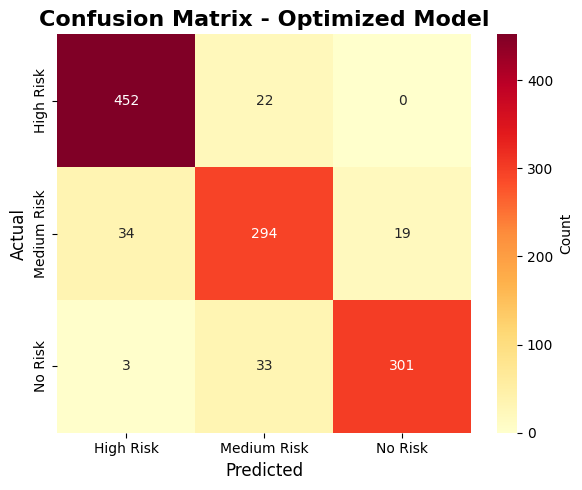


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   High Risk     0.9243    0.9536    0.9387       474
 Medium Risk     0.8424    0.8473    0.8448       347
     No Risk     0.9406    0.8932    0.9163       337

    accuracy                         0.9041      1158
   macro avg     0.9025    0.8980    0.8999      1158
weighted avg     0.9045    0.9041    0.9041      1158


PER-CLASS BREAKDOWN
High Risk       Accuracy: 0.9536
Medium Risk     Accuracy: 0.8473
No Risk         Accuracy: 0.8932


In [10]:
# ===================================================================
# CELL 8: EVALUATION
# ===================================================================
print("\n" + "="*50)
print("EVALUATING ON TEST SET")
print("="*50)

test_results = trainer.predict(test_dataset)
test_preds = test_results.predictions.argmax(-1)

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Optimized Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(test_labels, test_preds,
                          target_names=le.classes_,
                          digits=4))

# Per-class metrics
print("\n" + "="*50)
print("PER-CLASS BREAKDOWN")
print("="*50)
for i, label in enumerate(le.classes_):
    mask = test_labels == i
    class_acc = accuracy_score(test_labels[mask], test_preds[mask])
    print(f"{label:15} Accuracy: {class_acc:.4f}")

In [11]:
# ===================================================================
# CELL 9: SAVE MODEL
# ===================================================================
import json
import pickle

project_folder = '/content/drive/My Drive/MindShield/'
model_save_path = os.path.join(project_folder, 'MindShield_Best_Model(90)')

# Save model
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Save label encoder
with open(os.path.join(model_save_path, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

# Save metrics
final_metrics = {
    "test_accuracy": accuracy_score(test_labels, test_preds),
    "test_f1": f1_score(test_labels, test_preds, average='weighted'),
    "classification_report": classification_report(test_labels, test_preds,
                                                  target_names=le.classes_,
                                                  output_dict=True)
}

with open(os.path.join(model_save_path, "final_metrics.json"), "w") as f:
    json.dump(final_metrics, f, indent=4)

print("\n" + "="*50)
print("MODEL SAVED SUCCESSFULLY")
print("="*50)
print(f"Location: {model_save_path}")
print(f"Test Accuracy: {final_metrics['test_accuracy']:.4f}")
print(f"Test F1 Score: {final_metrics['test_f1']:.4f}")
print("="*50)


MODEL SAVED SUCCESSFULLY
Location: /content/drive/My Drive/MindShield/MindShield_Best_Model(90)
Test Accuracy: 0.9041
Test F1 Score: 0.9041
